In [51]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# On exécute le fichier forGrowth.py pour créer myData2
exec(open("forGrowth.py").read())

In [52]:
#  2.1 - 1.
print("Nombre de lignes :", myData2.shape[0])
print("Nombre de colonnes :", myData2.shape[1])
print("Noms des colonnes :", list(myData2.columns))
myData2.head()

Nombre de lignes : 57
Nombre de colonnes : 13
Noms des colonnes : ['GDP_Growth', 'HDebt_4Q', 'NFDebt_4Q', 'PDebt_4Q', 'TBills_4Q', 'Y10Years_4Q', 'IShPrices_4Q', 'HDebt_5Q', 'NFDebt_5Q', 'PDebt_5Q', 'TBills_5Q', 'Y10Years_5Q', 'IShPrices_5Q']


,GDP_Growth,HDebt_4Q,NFDebt_4Q,PDebt_4Q,TBills_4Q,Y10Years_4Q,IShPrices_4Q,HDebt_5Q,NFDebt_5Q,PDebt_5Q,TBills_5Q,Y10Years_5Q,IShPrices_5Q
0,0.233700,89.962,150.7,60.70087,2.536667,4.160000,0.293030,88.406,150.6,60.94141,2.006667,4.296667,6.780115
1,0.154633,91.030,152.2,60.35750,2.863333,4.213333,4.300951,89.962,150.7,60.70087,2.536667,4.160000,0.293030
2,0.851865,91.939,153.5,61.28277,3.360000,4.490000,-0.124079,91.030,152.2,60.35750,2.863333,4.213333,4.300951
3,0.235493,92.731,154.8,61.53482,3.826667,4.570000,8.455589,91.939,153.5,61.28277,3.360000,4.490000,-0.124079
4,0.572872,94.243,156.3,61.23753,4.393333,5.070000,4.357308,92.731,154.8,61.53482,3.826667,4.570000,8.455589


In [53]:
#  2.1 - 2.
# On utilise la médiane comme seuil
seuil2 = myData2["GDP_Growth"].median()
print("Seuil Cls2 (médiane) :", round(seuil2, 4))

myData2["Cls2"] = myData2["GDP_Growth"].apply(lambda x: "High" if x >= seuil2 else "Low")
print(myData2["Cls2"].value_counts())

Seuil Cls2 (médiane) : 0.5433
Cls2
High    29
Low     28
Name: count, dtype: int64


In [54]:
#  2.1 - 3.
# On utilise les percentiles 33% et 66% pour créer 3 classes équilibrées
q33 = myData2["GDP_Growth"].quantile(0.33)
q66 = myData2["GDP_Growth"].quantile(0.66)
print(f"Seuil 33% : {q33:.4f}, Seuil 66% : {q66:.4f}")

def cls3(x):
    if x < q33:
        return "Low"
    elif x < q66:
        return "Intermediate"
    else:
        return "High"

myData2["Cls3"] = myData2["GDP_Growth"].apply(cls3)
print(myData2["Cls3"].value_counts())

Seuil 33% : 0.3448, Seuil 66% : 0.6366
Cls3
High            20
Low             19
Intermediate    18
Name: count, dtype: int64


In [55]:
#  2.2 - 1.
X = myData2.drop(columns=["GDP_Growth", "Cls2", "Cls3"])
y = myData2["Cls2"]
y3 = myData2["Cls3"]

# Séparation train (70%) / test (30%) — même découpage pour Cls2 et Cls3
X_train, X_test, y_train, y_test = train_test_split(X, y,  test_size=0.3, random_state=100)
_, _,          y3_train, y3_test = train_test_split(X, y3, test_size=0.3, random_state=100)
print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")

# Boucle sur différents nombres d'arbres — entraînement sur train, évaluation sur test
resultats = []
for n in [10, 50, 100, 200, 500]:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=100)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))   # évaluation sur TEST
    oob = 1 - rf.oob_score_                            # OOB calculé sur train
    resultats.append({"n_arbres": n, "Accuracy_test": round(acc, 4), "OOB_error": round(oob, 4)})

df_res = pd.DataFrame(resultats)
print(df_res)

Train : 39 lignes | Test : 18 lignes
   n_arbres  Accuracy_test  OOB_error
0        10         0.2222     0.3846
1        50         0.2222     0.2564
2       100         0.2778     0.3333
3       200         0.2222     0.3077
4       500         0.2222     0.3077


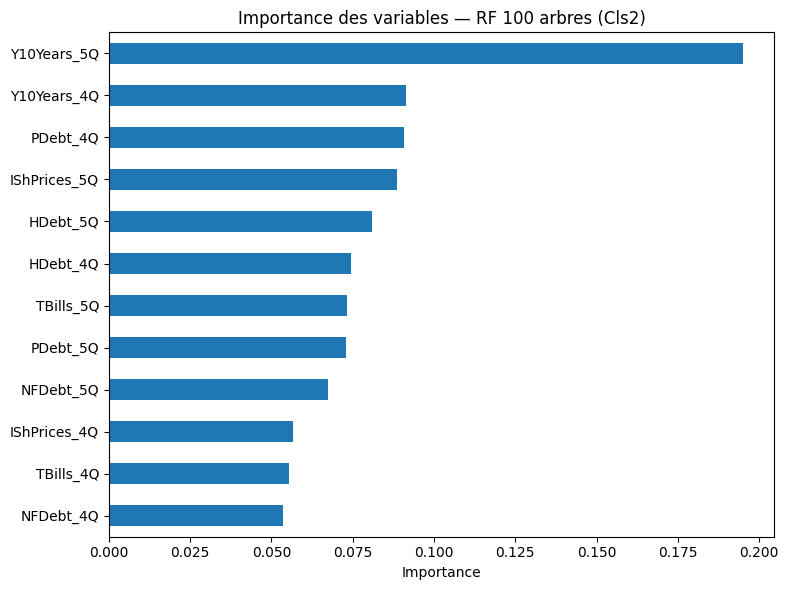

In [66]:
#  2.2 - 2.
best_rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=100)
best_rf.fit(X_train, y_train)   # entraîné sur train

importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh")
plt.title("Importance des variables — RF 100 arbres (Cls2)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [57]:
#  2.2 - 3.
top_vars = importances.sort_values(ascending=False).head(6).index.tolist()
print("Variables sélectionnées :", top_vars)

X_top_train = X_train[top_vars]
X_top_test  = X_test[top_vars]

rf_top = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=100)
rf_top.fit(X_top_train, y_train)

acc_top = accuracy_score(y_test, rf_top.predict(X_top_test))
oob_top = 1 - rf_top.oob_score_
print(f"Accuracy (test) : {acc_top:.4f}")
print(f"OOB error       : {oob_top:.4f}")

Variables sélectionnées : ['Y10Years_5Q', 'Y10Years_4Q', 'PDebt_4Q', 'IShPrices_5Q', 'HDebt_5Q', 'HDebt_4Q']
Accuracy (test) : 0.2778
OOB error       : 0.2821


In [58]:
#  2.2 - 4.
y_pred_top = rf_top.predict(X_top_test)
classes    = rf_top.classes_

mc = confusion_matrix(y_test, y_pred_top, labels=classes)
print("Matrice de confusion (test) :")
print(pd.DataFrame(mc, index=classes, columns=classes))

print("\nConclusion : la classe avec le moins de bons prédits en diagonale est la plus difficile à prédire.")

Matrice de confusion (test) :
      High  Low
High     1    3
Low     10    4

Conclusion : la classe avec le moins de bons prédits en diagonale est la plus difficile à prédire.


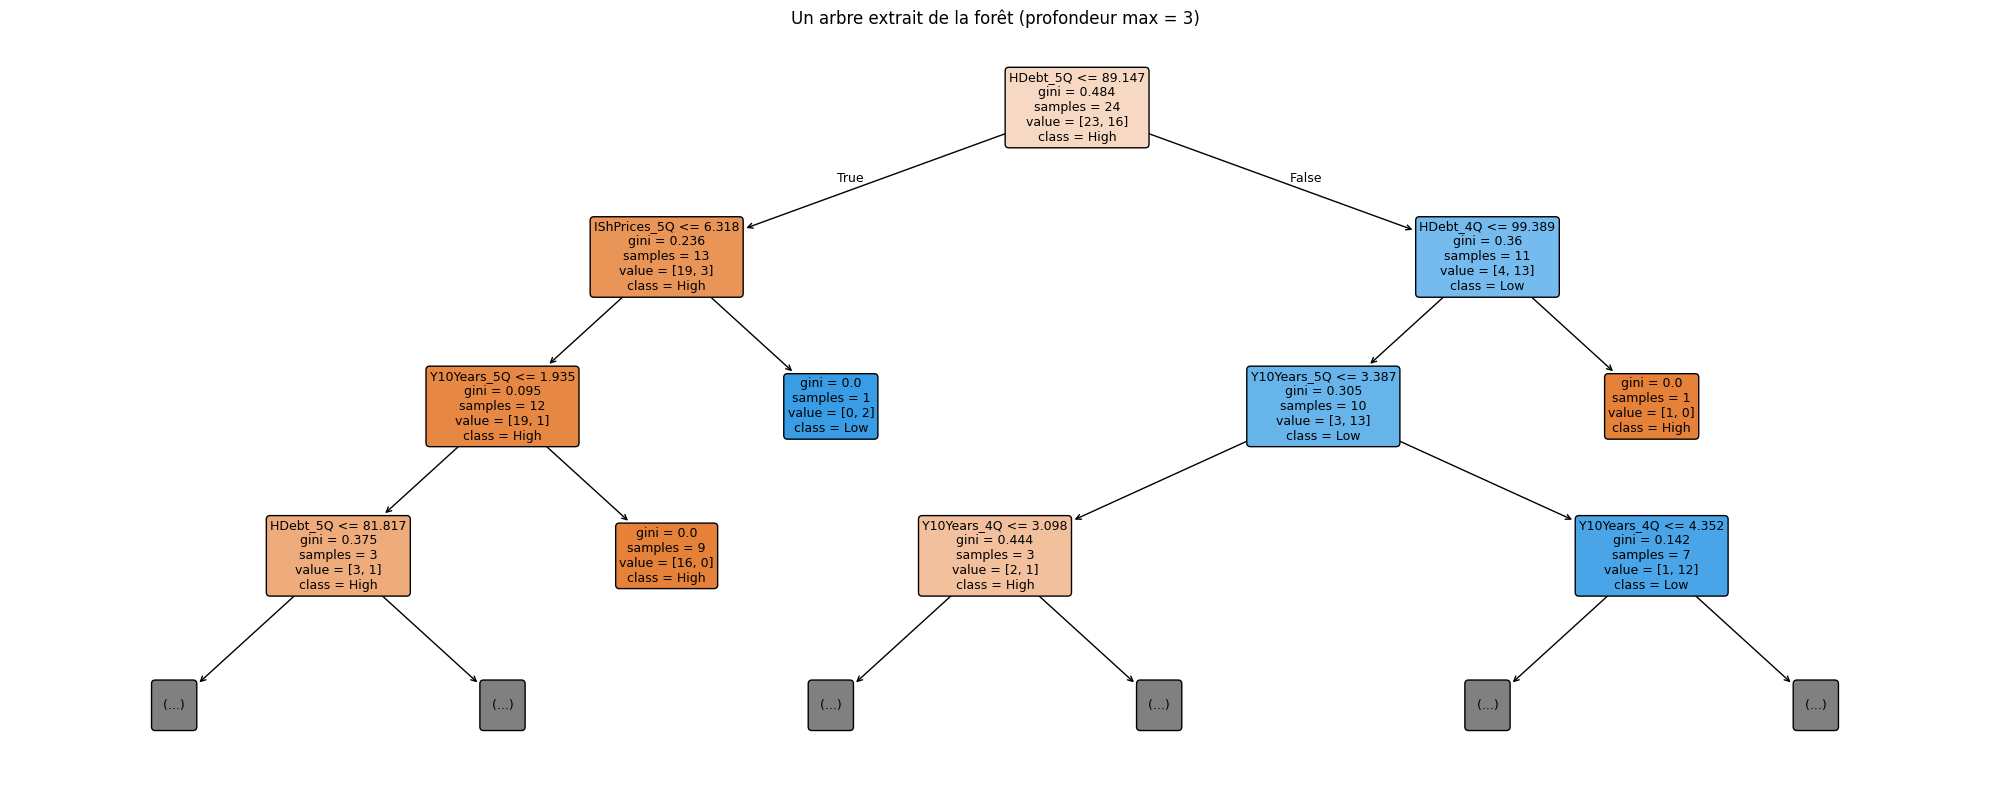

In [59]:
#  2.2 - 5.
from sklearn.tree import plot_tree

un_arbre = rf_top.estimators_[0]   # on prend le premier arbre

plt.figure(figsize=(20, 8))
plot_tree(un_arbre,
          feature_names=top_vars,
          class_names=classes,
          filled=True,
          rounded=True,
          max_depth=3,              # on limite la profondeur pour la lisibilité
          fontsize=9)
plt.title("Un arbre extrait de la forêt (profondeur max = 3)")
plt.tight_layout()
plt.show()

In [60]:
#  2.2 - 6.
rf_cls3 = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=100)
rf_cls3.fit(X_top_train, y3_train)

acc_cls3 = accuracy_score(y3_test, rf_cls3.predict(X_top_test))
oob_cls3 = 1 - rf_cls3.oob_score_
print(f"Accuracy (test) Cls3 : {acc_cls3:.4f}")
print(f"OOB error Cls3       : {oob_cls3:.4f}")

classes3 = rf_cls3.classes_
mc3 = confusion_matrix(y3_test, rf_cls3.predict(X_top_test), labels=classes3)
print("\nMatrice de confusion Cls3 (test) :")
print(pd.DataFrame(mc3, index=classes3, columns=classes3))

Accuracy (test) Cls3 : 0.1667
OOB error Cls3       : 0.4872

Matrice de confusion Cls3 (test) :
              High  Intermediate  Low
High             1             0    1
Intermediate     3             1    2
Low              7             2    1


### 2.2 - 7. Conclusion Random Forest

Les résultats montrent un overfitting important : l'accuracy sur le train est élevée mais l'OOB error reste importante pour Cls2 et encore plus pour Cls3, ce qui correspond à une performance proche du hasard sur des données non vues.
Cela s'explique principalement par la taille réduite du dataset (57 observations), qui ne permet pas à la forêt de bien généraliser. L'importance des variables reste néanmoins un résultat utile pour identifier les indicateurs les plus liés à la croissance du PIB.

In [61]:
#  2.3 - 1.
# On réutilise le même split train/test que pour la RF
nn_cls3 = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=100)
nn_cls3.fit(X_train, y3_train)
print("Réseau de neurones (Cls3) entraîné !")

Réseau de neurones (Cls3) entraîné !


c:\Etienne\Applications\Python\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [62]:
#  2.3 - 2.
acc_nn3 = accuracy_score(y3_test, nn_cls3.predict(X_test))
print(f"Accuracy (données brutes, test) : {acc_nn3:.4f}")

mc_nn3 = confusion_matrix(y3_test, nn_cls3.predict(X_test), labels=nn_cls3.classes_)
print("\nMatrice de confusion :")
print(pd.DataFrame(mc_nn3, index=nn_cls3.classes_, columns=nn_cls3.classes_))

Accuracy (données brutes, test) : 0.1667

Matrice de confusion :
              High  Intermediate  Low
High             0             2    0
Intermediate     2             2    2
Low              7             2    1


In [63]:
#  2.3 - 3.
print("Min et max de chaque variable explicative :\n")
print(X.agg(["min", "max"]).round(4))

Min et max de chaque variable explicative :

     HDebt_4Q  NFDebt_4Q  PDebt_4Q  TBills_4Q  Y10Years_4Q  IShPrices_4Q  \
min    75.181      147.2   60.3575     0.0133       1.5633      -27.2766   
max    99.822      170.0  105.0897     4.9833       5.0700       16.1368   

     HDebt_5Q  NFDebt_5Q  PDebt_5Q  TBills_5Q  Y10Years_5Q  IShPrices_5Q  
min    75.181      147.2   60.3575     0.0133       1.5633      -27.2766  
max    99.822      170.0  105.0897     4.9833       5.0700       16.1368  


### 2.3 - 4. Comment améliorer les performances du réseau ?

Les variables explicatives ont des échelles très différentes, ce qui pose problème pour un réseau de neurones : les variables avec de grandes valeurs vont dominer l'apprentissage au détriment des autres. La solution est de normaliser les données avec un StandardScaler, afin que chaque variable ait une moyenne de 0 et un écart-type de 1 avant d'entraîner le réseau.

In [64]:
#  2.3 - 5.
# on fit le scaler uniquement sur le train, puis on transforme les deux
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train)   # apprentissage du scaler sur train
X_scaled_test = scaler.transform(X_test)         # même transformation sur test

nn_cls3_v2 = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=2000, random_state=100)
nn_cls3_v2.fit(X_scaled_train, y3_train)

acc_v2 = accuracy_score(y3_test, nn_cls3_v2.predict(X_scaled_test))
print(f"Accuracy après normalisation (Cls3, test) : {acc_v2:.4f}")

mc_v2 = confusion_matrix(y3_test, nn_cls3_v2.predict(X_scaled_test), labels=nn_cls3_v2.classes_)
print("\nMatrice de confusion :")
print(pd.DataFrame(mc_v2, index=nn_cls3_v2.classes_, columns=nn_cls3_v2.classes_))

Accuracy après normalisation (Cls3, test) : 0.3333

Matrice de confusion :
              High  Intermediate  Low
High             0             2    0
Intermediate     1             3    2
Low              5             2    3


In [65]:
#  2.3 - 6.
nn_cls2 = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=2000, random_state=100)
nn_cls2.fit(X_scaled_train, y_train)

acc_cls2 = accuracy_score(y_test, nn_cls2.predict(X_scaled_test))
print(f"Accuracy (Cls2, normalisé, test) : {acc_cls2:.4f}")

mc_cls2 = confusion_matrix(y_test, nn_cls2.predict(X_scaled_test), labels=nn_cls2.classes_)
print("\nMatrice de confusion :")
print(pd.DataFrame(mc_cls2, index=nn_cls2.classes_, columns=nn_cls2.classes_))

Accuracy (Cls2, normalisé, test) : 0.4444

Matrice de confusion :
      High  Low
High     2    2
Low      8    6


### 2.3 - 7. Conclusion Réseau de neurones

Sans normalisation, le réseau donne de mauvais résultats à cause des échelles très différentes entre les variables. Après normalisation, les performances s'améliorent.

Comme pour la forêt aléatoire, prédire Cls2 est plus facile que Cls3, la classe Intermediate étant la plus difficile à classer correctement.

Les deux modèles donnent des résultats similaires, mais la forêt aléatoire reste plus facile à interpréter grâce à l'importance des variables et aux règles des arbres.